In [22]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [23]:
curr_dir_path = os.getcwd()
main_dir_path = os.path.abspath(os.path.join(curr_dir_path, os.pardir))
data_dir_path = os.path.join(main_dir_path, 'data')
raw_data_dir_path = os.path.join(data_dir_path, 'raw_data')
processed_data_dir_path = os.path.join(data_dir_path, 'processed_data')
cw_dir_path = os.path.join(data_dir_path, 'cw')
emissions_data_dir_path = os.path.join(raw_data_dir_path, 'emissions_data')
iea_data_dir_path = os.path.join(raw_data_dir_path, 'IEA_climate_policy_data')

In [24]:
IEA_policies_df = pd.read_csv(os.path.join(iea_data_dir_path, 'IEA_PAMS_Export 1_29_2025, 6_11_31 PM.csv'))
IEA_policies_df.head()

,year,jurisdiction,title,description,status,ISO3,country,topic,type,category,source
0,2011.0,National,Law 47-09 on Energy Efficiency,"Law 47-09, or the ""Law on Energy Efficiency"" a...",In force,MAR,Morocco,NaN,NaN,NaN,http://www.muat.gov.ma/sites/default/files/Reg...
1,2017.0,National,Swiss Energy Strategy 2050,Swiss Energy Strategy 2050The Swiss Energy Str...,In force,CHE,Switzerland,Economy-wide,"Master Energy Plan,Framework legislation",NaN,https://www.uvek.admin.ch/uvek/de/home/energie...
2,2009.0,National,Buy Smart project,"The aim of the Buy Smart""- project is to promo...",Ended,DEU,Germany,NaN,NaN,NaN,https://www.european-energy-award.de/european-...
3,2010.0,National,A Group of Energy Efficiency Measures in Agric...,This group consists of five PAMs.1. Biomass bo...,In force,FIN,Finland,NaN,NaN,NaN,http://www.mmm.fi/en/index/frontpage.html
4,1999.0,National,New Buses,Financial assistance to regions and municipali...,In force,ITA,Italy,NaN,NaN,NaN,NaN


In [25]:
# Make all col names lowercase
IEA_policies_df.columns = IEA_policies_df.columns.str.lower()

# drop source column
IEA_policies_df = IEA_policies_df.drop(columns=['source'])

## Data Integrity and Initial Cleaning

### Missing data in important columns
- year.
- iso3.

In [26]:
IEA_policies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13155 entries, 0 to 13154
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          13127 non-null  float64
 1   jurisdiction  13155 non-null  object 
 2   title         13155 non-null  object 
 3   description   13119 non-null  object 
 4   status        13155 non-null  object 
 5   iso3          13149 non-null  object 
 6   country       13155 non-null  object 
 7   topic         7046 non-null   object 
 8   type          7046 non-null   object 
 9   category      3630 non-null   object 
dtypes: float64(1), object(9)
memory usage: 1.0+ MB


In [27]:
# Check for duplicates
duplicates = IEA_policies_df.duplicated(keep='first')
duplicates.value_counts()

False    12739
True       416
Name: count, dtype: int64

In [28]:
# Eliminate duplicates
IEA_policies_df = IEA_policies_df.drop_duplicates()

In [29]:
# Check for NaN in year column
IEA_policies_df['year'].isnull().value_counts()

year
False    12712
True        27
Name: count, dtype: int64

In [30]:
# Print null cols where year is null
# IEA_policies_df[IEA_policies_df['year'].isnull()]

In [31]:
# For now let's drop the rows with NaN in year column
IEA_policies_df = IEA_policies_df.dropna(subset=['year'])

In [32]:
# set year column to integer
IEA_policies_df['year'] = IEA_policies_df['year'].astype(int)

In [33]:
# Check for NaN in iso3 column
IEA_policies_df['iso3'].isnull().value_counts()

iso3
False    12707
True         5
Name: count, dtype: int64

In [34]:
# Check the records with missing iso3
IEA_policies_df[IEA_policies_df['iso3'].isnull()]

,year,jurisdiction,title,description,status,iso3,country,topic,type,category
226,2013,International,Climate Technology Centre and Network Technica...,The Climate Technology Centre and Network (CTC...,In force,NaN,Unknown,NaN,NaN,NaN
229,2009,International,The World Bank Carbon Capture and Storage Capa...,"The World Bank CCS Trust Fund, established in ...",In force,NaN,Unknown,NaN,NaN,NaN
3325,2015,International,The Vatican’s Laudato Si’ Action Platform,Pope Francis issued the Laudato Si’ encyclical...,In force,NaN,Vatican City,People-Centred Clean Energy Transitions,"Socioeconomic development,,Public participation,",NaN
3342,2008,National,Vatican installation of PV system,"To help green its operations, as promoted by P...",In force,NaN,Vatican City,People-Centred Clean Energy Transitions,"Energy security and resilience,,Public partici...",NaN
5019,2019,International,LEAP-RE,LEAP-RE is a mechanism for funding R&amp;D and...,In force,NaN,African Union,Technology R&D and innovation,"Grants,Resource push",Grants for R&D projects


In [35]:
# Drop rows with NaN in iso3 column
IEA_policies_df = IEA_policies_df.dropna(subset=['iso3'])

In [36]:
# Check jurisdiction column
IEA_policies_df['jurisdiction'].unique()

array(['National', 'City/Municipal', 'State/Provincial', 'International',
       'Unknown', 'Other', 'Regional', 'National '], dtype=object)

In [37]:
# Replace the 'National ' values to 'National' in the jurisdiction column
IEA_policies_df.loc[IEA_policies_df['jurisdiction'] == 'National ', 'jurisdiction'] = 'National'

In [38]:
IEA_policies_df['jurisdiction'].unique()

array(['National', 'City/Municipal', 'State/Provincial', 'International',
       'Unknown', 'Other', 'Regional'], dtype=object)

In [39]:
IEA_policies_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12707 entries, 0 to 13154
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   year          12707 non-null  int64 
 1   jurisdiction  12707 non-null  object
 2   title         12707 non-null  object
 3   description   12672 non-null  object
 4   status        12707 non-null  object
 5   iso3          12707 non-null  object
 6   country       12707 non-null  object
 7   topic         6636 non-null   object
 8   type          6636 non-null   object
 9   category      3294 non-null   object
dtypes: int64(1), object(9)
memory usage: 1.1+ MB


In [40]:
IEA_policies_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12707 entries, 0 to 13154
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   year          12707 non-null  int64 
 1   jurisdiction  12707 non-null  object
 2   title         12707 non-null  object
 3   description   12672 non-null  object
 4   status        12707 non-null  object
 5   iso3          12707 non-null  object
 6   country       12707 non-null  object
 7   topic         6636 non-null   object
 8   type          6636 non-null   object
 9   category      3294 non-null   object
dtypes: int64(1), object(9)
memory usage: 1.1+ MB


In [41]:
# Fill NaNs with Unknown
# IEA_policies_df = IEA_policies_df.fillna('Unknown')

## Understanding the Data

- Num of regions: 217


In [42]:
# How many countries we have?
IEA_policies_df['country'].unique()

array(['Morocco', 'Switzerland', 'Germany', 'Finland', 'Italy', 'Greece',
       'Netherlands', "People's Republic of China", 'Turkiye', 'France',
       'United States', 'New Zealand', 'Canada', 'Norway', 'Spain',
       'Luxembourg', 'Sweden', 'Australia', 'European Union',
       'United Arab Emirates', 'United Kingdom', 'Portugal', 'Tunisia',
       'Brazil', 'Korea', 'Hungary', 'Japan', 'Russian Federation',
       'Denmark', 'Czechia', 'Turkmenistan', 'Singapore', 'India',
       'Belgium', 'Lithuania', 'Poland', 'Ireland', 'Mexico', 'Viet Nam',
       'Bolivarian Republic of Venezuela', 'Argentina', 'Israel',
       'Ukraine', 'Costa Rica', 'Peru', 'Jordan', 'Malaysia', 'Uruguay',
       'Saudi Arabia', 'Ghana', 'Pakistan', 'Belarus', 'Panama',
       'Tajikistan', 'Armenia', 'Barbados', 'Kenya', 'Nigeria', 'Iceland',
       'Mauritius', 'Zimbabwe', 'Azerbaijan', 'Philippines', 'Angola',
       'Ethiopia', 'Namibia', 'Jamaica', 'Afghanistan', 'Bahrain',
       'Benin', 'Banglade

In [43]:
# Print the amount of countries
len(IEA_policies_df['country'].unique())

217

In [44]:
# How many policies each country has?
policies_per_country_df = IEA_policies_df['country'].value_counts().reset_index()
policies_per_country_df.columns = ['country', 'policy_count']
policies_per_country_df

,country,policy_count
0,United States,759
1,Australia,468
2,Canada,436
3,People's Republic of China,397
4,United Kingdom,347
...,...,...
212,Falkland Islands (Malvinas),1
213,Pitcairn,1
214,Bermuda,1
215,French Southern Territories,1


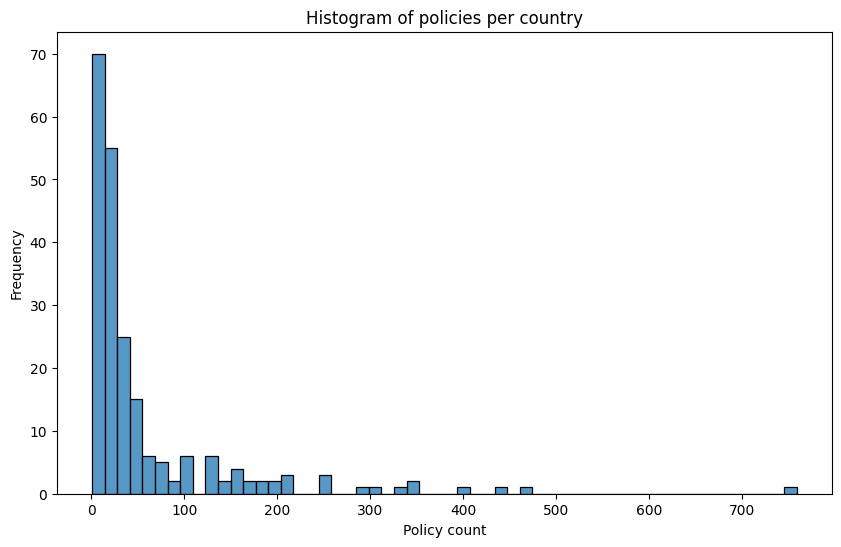

In [45]:
# Histogram of policies per country
plt.figure(figsize=(10, 6))
sns.histplot(policies_per_country_df['policy_count'])
plt.title('Histogram of policies per country')
plt.xlabel('Policy count')
plt.ylabel('Frequency')
plt.show()


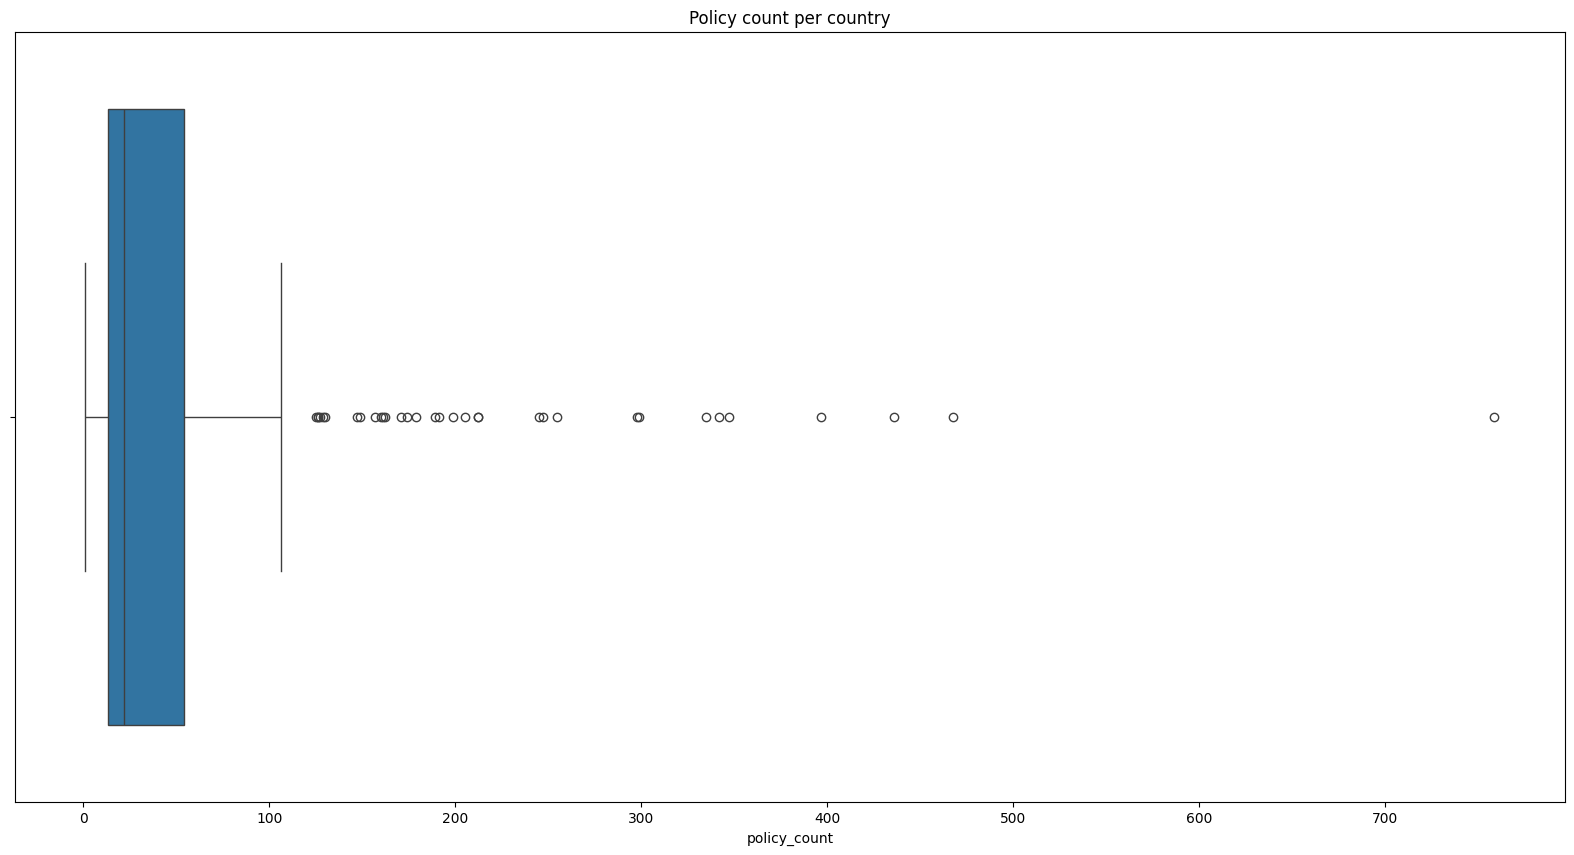

In [46]:
# Boxplot of policy count per country
plt.figure(figsize=(20, 10))
sns.boxplot(data=policies_per_country_df, x='policy_count')
plt.title('Policy count per country')
plt.show()

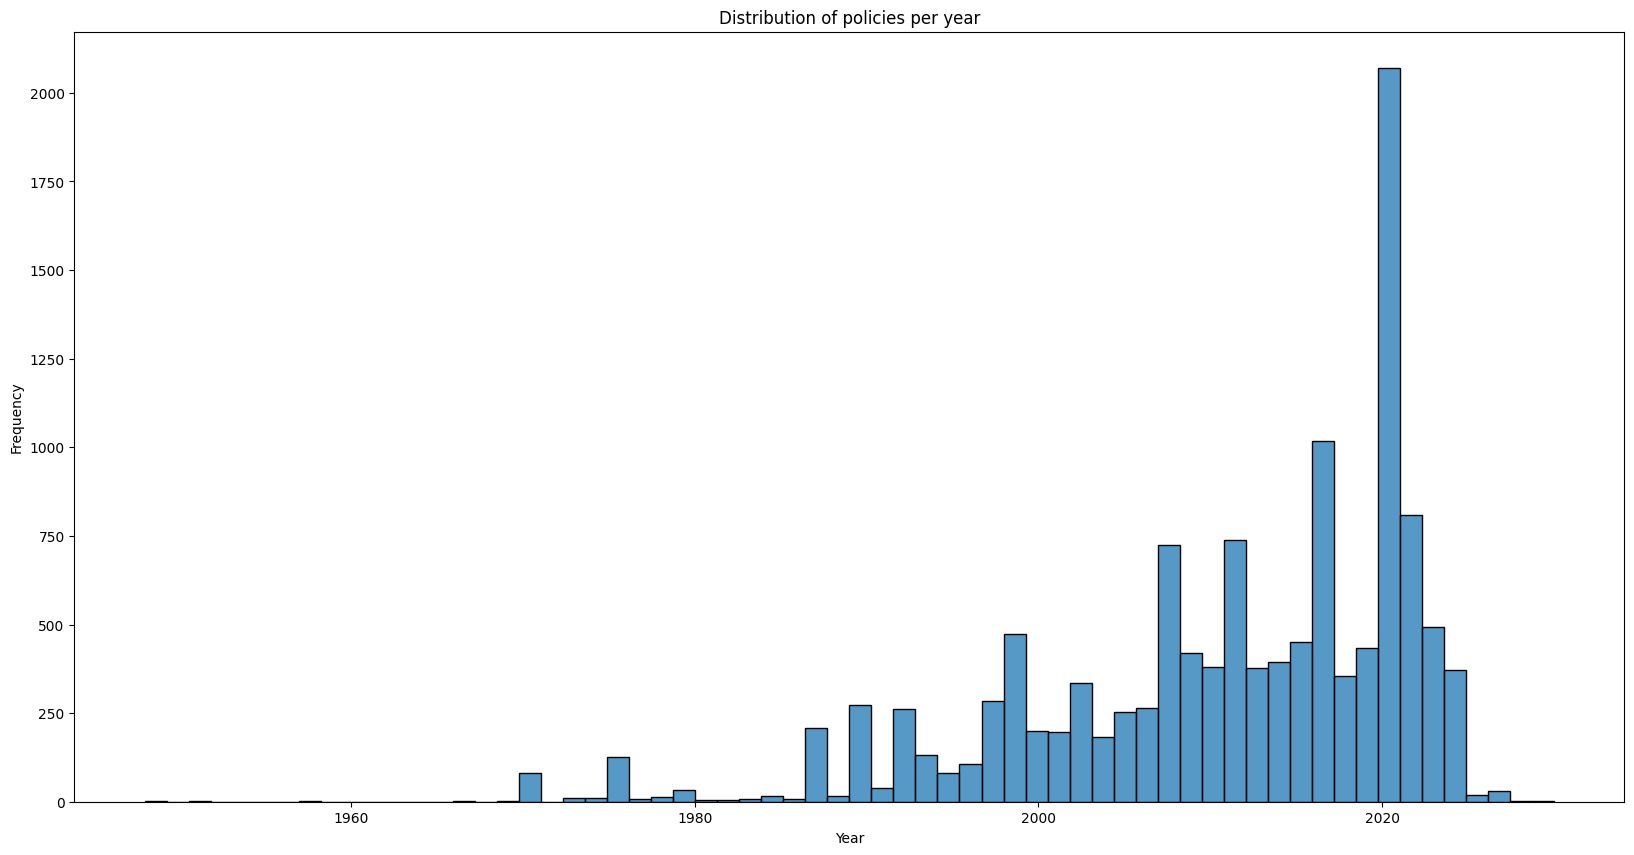

In [47]:
# Check the distribution of policies per year
plt.figure(figsize=(20, 10))
sns.histplot(IEA_policies_df['year'])
plt.title('Distribution of policies per year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

In [48]:
IEA_policies_df.columns

Index(['year', 'jurisdiction', 'title', 'description', 'status', 'iso3',
       'country', 'topic', 'type', 'category'],
      dtype='object')

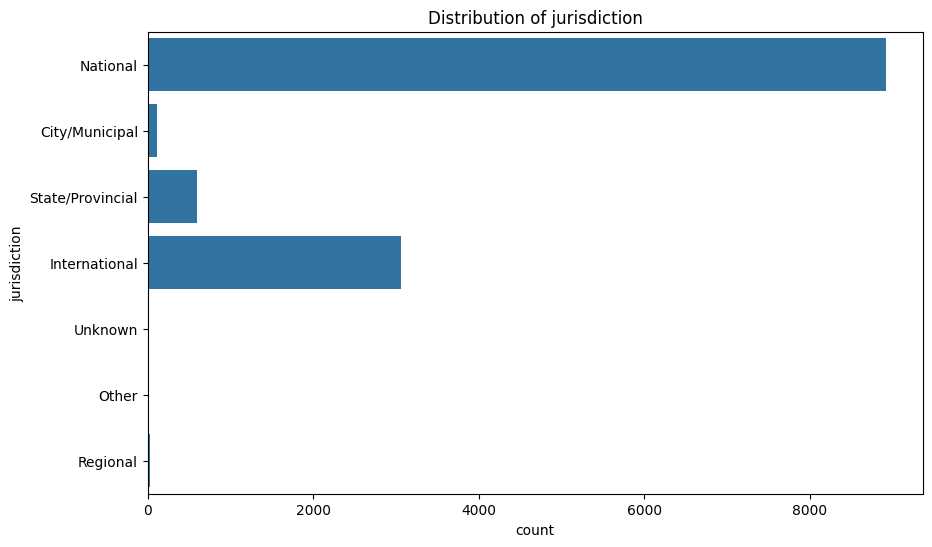

In [49]:
# Plot distribution of jurisdiction
plt.figure(figsize=(10, 6))
sns.countplot(data=IEA_policies_df, y='jurisdiction')
plt.title('Distribution of jurisdiction')
plt.show()

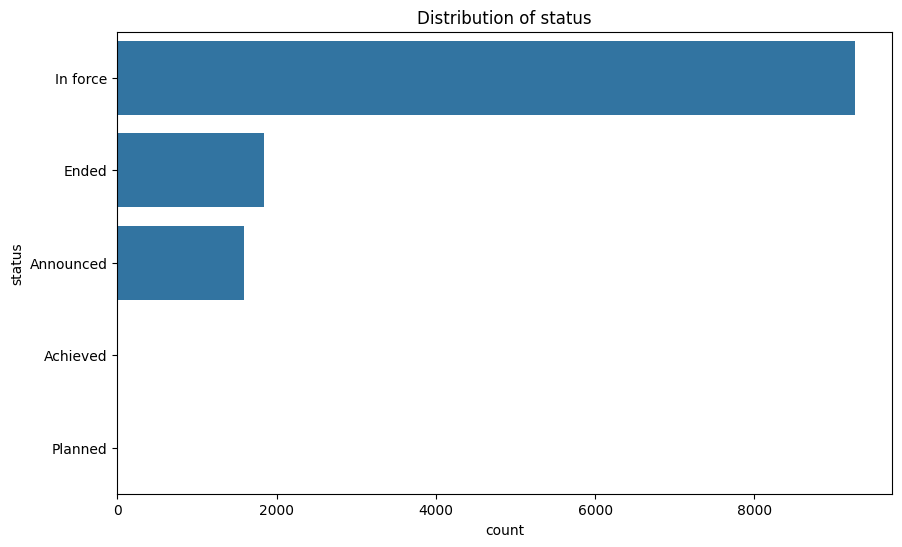

In [50]:
# Plot distribution of status
plt.figure(figsize=(10, 6))
sns.countplot(data=IEA_policies_df, y='status')
plt.title('Distribution of status')
plt.show()


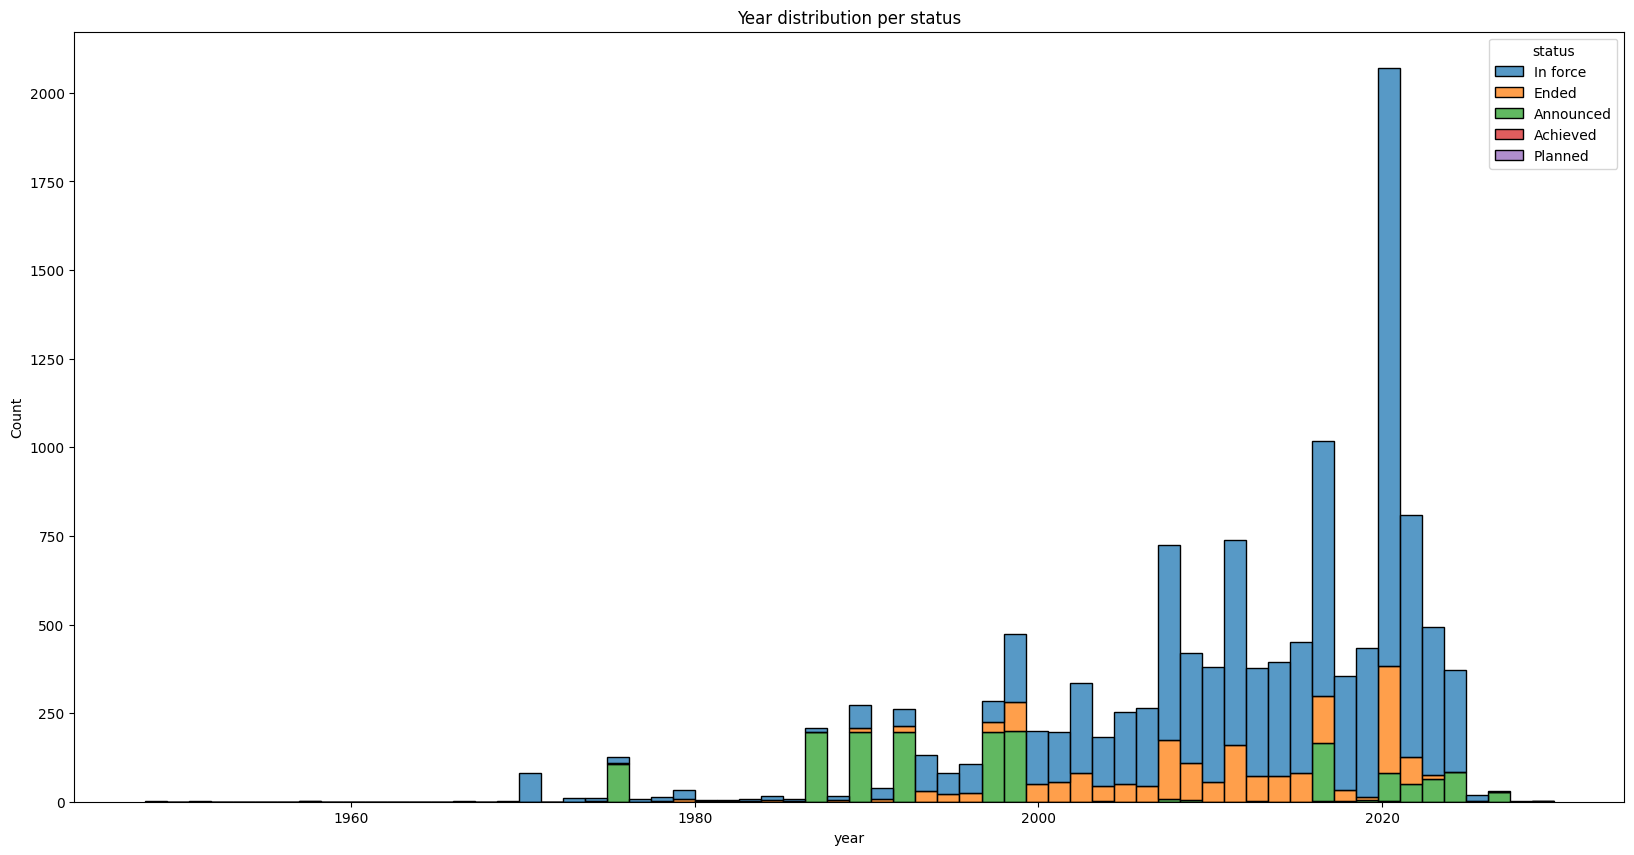

In [51]:
# Plot year distribution per status
plt.figure(figsize=(20, 10))
sns.histplot(data=IEA_policies_df, x='year', hue='status', multiple='stack')
plt.title('Year distribution per status')
plt.show()

## Additional Cleaning and Exploration

In [52]:
# Filter out the policies that have a status of 'Announced', 'Planned'
IEA_policies_df = IEA_policies_df[~IEA_policies_df['status'].isin(['Announced', 'Planned'])]

In [53]:
# Check for repeated values in title column

# Group by title and collect the years for each title
grouped_by_title_year = IEA_policies_df.groupby('title')['year'].unique().reset_index()

# Filter for titles that appear in more than one year
repeated_titles_in_diff_years = grouped_by_title_year[grouped_by_title_year['year'].apply(lambda x: len(x) > 1)]
repeated_titles_in_diff_years.head()

,title,year
575,"Act on the Promotion of the Development, Use a...","[1988, 2004]"
938,Bio-energy Infrastructure Scheme,"[2004, 2003]"
983,Biofuels blending mandate,"[2013, 2011]"
1068,Building Code of Australia (Non-residential B...,"[2013, 2014]"
1070,Building Code of Australia (Multi-Occupancy Bu...,"[2012, 2013, 2014, 2015]"


In [54]:
IEA_policies_df[IEA_policies_df['title'] == 'Building Code of Australia (Residential Building)']

,year,jurisdiction,title,description,status,iso3,country,topic,type,category
12216,2012,National,Building Code of Australia (Residential Building),NCC 2012 Complete Series contains NCC 2012 Vol...,Ended,AUS,Australia,NaN,NaN,NaN
12217,2013,National,Building Code of Australia (Residential Building),NCC 2013 Complete Series contains NCC 2013 Vol...,Ended,AUS,Australia,NaN,NaN,NaN
12218,2014,National,Building Code of Australia (Residential Building),NCC 2014 Complete Series contains NCC 2014 Vol...,Ended,AUS,Australia,NaN,NaN,NaN
12220,2016,National,Building Code of Australia (Residential Building),NCC 2016 Complete Series contains NCC 2016 Vol...,Ended,AUS,Australia,NaN,NaN,NaN


In [55]:
# Group by title and collect the status for each title
grouped_by_title_status = IEA_policies_df.groupby('title')['status'].unique().reset_index()

# Filter for titles that appear in more than one status
repeated_titles_in_diff_status = grouped_by_title_status[grouped_by_title_status['status'].apply(lambda x: len(x) > 1)]
repeated_titles_in_diff_status

,title,status
436,2nd National Energy Efficiency Target Programme,"[Ended, In force]"
575,"Act on the Promotion of the Development, Use a...","[Ended, In force]"
938,Bio-energy Infrastructure Scheme,"[In force, Ended]"
1070,Building Code of Australia (Multi-Occupancy Bu...,"[Ended, In force]"
1310,Carbon Tax,"[In force, Ended]"
2491,Energy Act,"[Ended, In force]"
2574,Energy Efficiency Fund,"[Ended, In force]"
2598,Energy Efficiency Obligation,"[In force, Ended]"
2869,Energy efficiency requirement for non-duct air...,"[Ended, In force]"
3305,Feed-in tariffs for renewable energy,"[In force, Ended]"


In [56]:
IEA_policies_df[IEA_policies_df['title'] == 'Integrated Energy Policy']

,year,jurisdiction,title,description,status,iso3,country,topic,type,category
2289,2006,National,Integrated Energy Policy,At the direction of the Prime Minister and Dep...,In force,IND,India,NaN,NaN,NaN
9987,2005,National,Integrated Energy Policy,At the direction of the Prime Minister and Dep...,Ended,IND,India,NaN,NaN,NaN


In [57]:
IEA_policies_df.loc[10123, 'description']

'Round 1\xa0of the Bio-Energy Infrastructure Scheme was launched in 2003.The scheme provides grants to stimulate the small-scale biomass suppliers fuel for use in heat and electricity generation.\xa0Biomass producers and small- or medium-sized enterprises are eligible to apply for\xa0grants of up to a GBP 200,000 per producer group or business. The project must be based in England and supply biomass to users in Britain.Eligible crops include:\xa0Short rotation coppice (willow, poplar, alder, ash, hazel, lime, silver birch, sweet chestnut and sycamore), miscanthus, switch grass, reed canary grass, prairie cord grass, rye grass, and straw. Wood fuel produced directly from forestry, arboricultural tree management and primary processing are also eligible. Any wood fuel coming from secondary processing, or from chemically treated or painted wood will be excluded. Also excluded are oilseed rape, biomass for transport fuels, and animal waste products.The grants will help fund administrative s

In [58]:
# Check duplicated rows with same title and iso3
duplicates = IEA_policies_df.duplicated(subset=['title', 'iso3'], keep='first')
# duplicates.value_counts()

# Create a subset of duplicated rows
duplicated_rows = IEA_policies_df[duplicates]
duplicated_rows.head()


,year,jurisdiction,title,description,status,iso3,country,topic,type,category
534,2019,National,National Hydrogen Strategy,"On 24 February 2023, the Energy and Climate Ch...",In force,AUS,Australia,Economy-wide,"Master Energy Plan,Framework legislation",NaN
577,2019,National,Roadmap for Carbon Recycling Technologies,"In 2019, the Ministry of Economy, Trade and In...",In force,JPN,Japan,NaN,NaN,NaN
641,2009,National,Energy Efficiency Project Grants\t,Energy Efficiency Project Grant were implement...,In force,TUR,Turkiye,NaN,NaN,NaN
646,2017,National,ENERGY STAR for New Homes,The ENERGY STAR® label ensures that new homes ...,In force,CAN,Canada,NaN,NaN,NaN
1521,2016,National,National Greenhouse and Energy Reporting (Safe...,The Safeguard Mechanism requires Australia’s l...,In force,AUS,Australia,Methane abatement,"Reduction targets,Framework legislation,Emissi...",Oil and natural gas extraction


In [59]:
IEA_policies_df[IEA_policies_df['title'] == 'National Hydrogen Strategy']

,year,jurisdiction,title,description,status,iso3,country,topic,type,category
533,2020,National,National Hydrogen Strategy,The Advancing Hydrogen Fund announced its Nati...,In force,AUS,Australia,"Fuels,Power","Government spending in low-carbon electricity,...",Hydro
534,2019,National,National Hydrogen Strategy,"On 24 February 2023, the Energy and Climate Ch...",In force,AUS,Australia,Economy-wide,"Master Energy Plan,Framework legislation",NaN
2876,2021,National,National Hydrogen Strategy,Morocco's National Hydrogen Strategy design th...,In force,MAR,Morocco,NaN,NaN,NaN
2885,2022,National,National Hydrogen Strategy,The Ministry of Trade and Industry published i...,In force,SGP,Singapore,NaN,NaN,NaN


In [60]:
IEA_policies_df

,year,jurisdiction,title,description,status,iso3,country,topic,type,category
0,2011,National,Law 47-09 on Energy Efficiency,"Law 47-09, or the ""Law on Energy Efficiency"" a...",In force,MAR,Morocco,NaN,NaN,NaN
1,2017,National,Swiss Energy Strategy 2050,Swiss Energy Strategy 2050The Swiss Energy Str...,In force,CHE,Switzerland,Economy-wide,"Master Energy Plan,Framework legislation",NaN
2,2009,National,Buy Smart project,"The aim of the Buy Smart""- project is to promo...",Ended,DEU,Germany,NaN,NaN,NaN
3,2010,National,A Group of Energy Efficiency Measures in Agric...,This group consists of five PAMs.1. Biomass bo...,In force,FIN,Finland,NaN,NaN,NaN
4,1999,National,New Buses,Financial assistance to regions and municipali...,In force,ITA,Italy,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
13150,1996,National,Voluntary Energy Audits,The Grand Ducal regulation of 11 August 1996 o...,In force,LUX,Luxembourg,NaN,NaN,NaN
13151,2008,National,Carbon Emissions Reduction Target (Energy Effi...,The Carbon Emissions Reduction Target (CERT) -...,Ended,GBR,United Kingdom,NaN,NaN,NaN
13152,2009,National,Saving energy by the organizations of local au...,The programmes concern the implementation of i...,Ended,GRC,Greece,NaN,NaN,NaN
13153,2006,National,Public Transit Capital Trust,Canada's Federal Budget 2006 dedicated CAD 1.3...,In force,CAN,Canada,NaN,NaN,NaN


In [63]:
IEA_policies_df.to_csv(os.path.join(processed_data_dir_path, 'IEA_policies_clean.csv'), index=False)

### Plot Policies versus emissions

In [ ]:
emissions_db = pd.read_csv(os.path.join(emissions_data_dir_path, 'CSC-GHG_emissions-April2024_to_calibrate.csv'), encoding='latin1')
emissions_db.head()

,Code,Country,EDGAR Country Code,Income group,Lending category,Region,CSC Sector,CSC Subsector,Gas,Units,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,ABW,Aruba,ABW,High income,NaN,Latin America & Caribbean,Energy,EN - Building,CH4,MtCO2e,...,0.000554,0.000538,0.000500,0.000570,0.000542,0.000574,0.000471,0.000616,0.000617,0.000622
1,ABW,Aruba,ABW,High income,NaN,Latin America & Caribbean,Energy,EN - Building,CO2,MtCO2e,...,0.047090,0.037332,0.035079,0.039403,0.035488,0.044616,0.050051,0.044068,0.042466,0.044068
2,ABW,Aruba,ABW,High income,NaN,Latin America & Caribbean,Energy,EN - Building,N2O,MtCO2e,...,0.000160,0.000138,0.000130,0.000137,0.000135,0.000235,0.000264,0.000240,0.000234,0.000241
3,ABW,Aruba,ABW,High income,NaN,Latin America & Caribbean,Energy,EN - Electricity/Heat,CH4,MtCO2e,...,0.000114,0.000120,0.000126,0.000127,0.000122,0.000132,0.000156,0.000135,0.000132,0.000136
4,ABW,Aruba,ABW,High income,NaN,Latin America & Caribbean,Energy,EN - Electricity/Heat,CO2,MtCO2e,...,0.213816,0.222204,0.229352,0.239740,0.223555,0.232325,0.274290,0.232537,0.224081,0.232537


In [ ]:
# Create a df with the total emissions per year by summing all float cols through axis=0
emission_totals = emissions_db.select_dtypes(include=[np.number]).sum(axis=0).reset_index()
emission_totals.columns = ['year', 'emission_total']
emission_totals['year'] = emission_totals['year'].astype(int)
emission_totals

,year,emission_total
0,2000,35749.969052
1,2001,35366.076858
2,2002,36351.340819
3,2003,38685.869626
4,2004,40922.501207
5,2005,41308.170804
6,2006,42804.911168
7,2007,42978.245611
8,2008,43156.258982
9,2009,42388.952207


In [ ]:
emission_totals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            23 non-null     int64  
 1   emission_total  23 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 500.0 bytes


In [ ]:
# Create a df with the number of policies per year
policies_per_year = IEA_policies_df['year'].value_counts().reset_index()
policies_per_year.columns = ['year', 'policy_count']
policies_per_year.sort_values('year', inplace=True)
policies_per_year.reset_index(drop=True, inplace=True)

# Calculate the cumulative sum of policies
policies_per_year['accumulated_policy_count'] = policies_per_year['policy_count'].cumsum()
policies_per_year

,year,policy_count,accumulated_policy_count
0,2000,148,148
1,2001,140,288
2,2002,138,426
3,2003,117,543
4,2004,137,680
5,2005,205,885
6,2006,220,1105
7,2007,251,1356
8,2008,299,1655
9,2009,311,1966


In [ ]:
policies_per_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   year                      23 non-null     int64
 1   policy_count              23 non-null     int64
 2   accumulated_policy_count  23 non-null     int64
dtypes: int64(3)
memory usage: 684.0 bytes


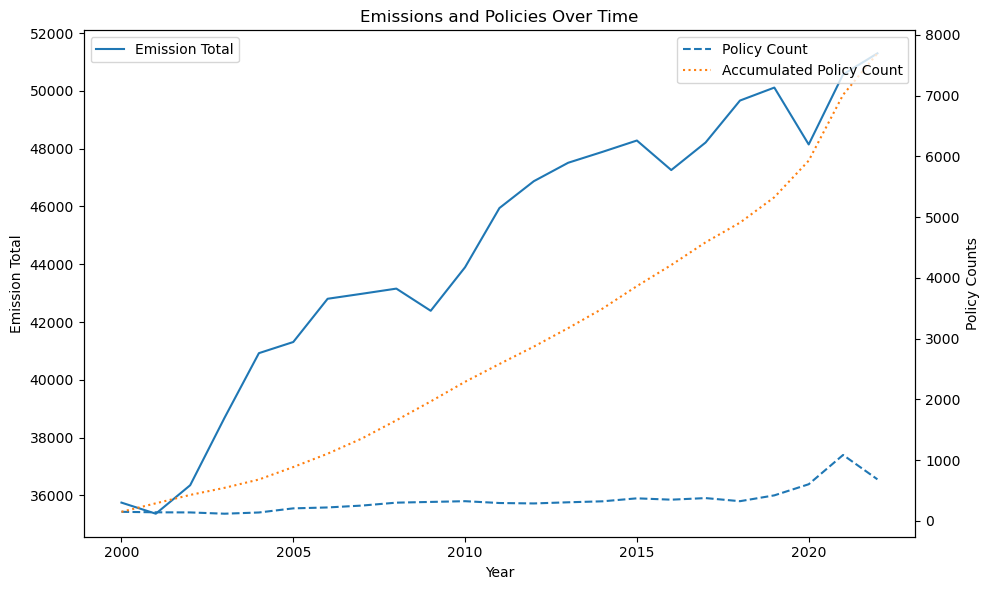

In [ ]:
# Assume your dataframes are named emission_totals and policies_per_year

fig, ax1 = plt.subplots(figsize=(10, 6))

# First plot (left y-axis)
ax1.plot(emission_totals['year'], emission_totals['emission_total'], label='Emission Total')
ax1.set_xlabel('Year')
ax1.set_ylabel('Emission Total')

# Create a second y-axis
ax2 = ax1.twinx()

# Second plot (right y-axis) – you can plot both the policy_count and accumulated_policy_count here 
# if you want them on the same scale or separate lines
ax2.plot(policies_per_year['year'], policies_per_year['policy_count'], label='Policy Count', linestyle='--')
ax2.plot(policies_per_year['year'], policies_per_year['accumulated_policy_count'], label='Accumulated Policy Count', linestyle=':')
ax2.set_ylabel('Policy Counts')

# Add a title, manage legends
plt.title('Emissions and Policies Over Time')

# Show legends – one for each axis
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Which countries have the largest emissions and the most policies? 

In [ ]:
emissions_db = emissions_db.drop(columns=['Country', 'EDGAR Country Code', 'Income group', 'Lending category', 'Region', 'CSC Sector', 'Units'])
emissions_db.head()

,Code,CSC Subsector,Gas,2000,2001,2002,2003,2004,2005,2006,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,ABW,EN - Building,CH4,0.000202,0.000214,0.000218,0.000244,0.000263,0.000242,0.000218,...,0.000554,0.000538,0.000500,0.000570,0.000542,0.000574,0.000471,0.000616,0.000617,0.000622
1,ABW,EN - Building,CO2,0.021251,0.023579,0.023320,0.027214,0.032069,0.026398,0.019531,...,0.047090,0.037332,0.035079,0.039403,0.035488,0.044616,0.050051,0.044068,0.042466,0.044068
2,ABW,EN - Building,N2O,0.000218,0.000221,0.000195,0.000211,0.000249,0.000283,0.000234,...,0.000160,0.000138,0.000130,0.000137,0.000135,0.000235,0.000264,0.000240,0.000234,0.000241
3,ABW,EN - Electricity/Heat,CH4,0.000073,0.000075,0.000079,0.000091,0.000095,0.000101,0.000111,...,0.000114,0.000120,0.000126,0.000127,0.000122,0.000132,0.000156,0.000135,0.000132,0.000136
4,ABW,EN - Electricity/Heat,CO2,0.131217,0.133759,0.137867,0.166334,0.171255,0.196176,0.215872,...,0.213816,0.222204,0.229352,0.239740,0.223555,0.232325,0.274290,0.232537,0.224081,0.232537


In [ ]:
emissions_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6624 entries, 0 to 6623
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Code           6624 non-null   object 
 1   CSC Subsector  6624 non-null   object 
 2   Gas            6624 non-null   object 
 3   2000           6583 non-null   float64
 4   2001           6583 non-null   float64
 5   2002           6583 non-null   float64
 6   2003           6583 non-null   float64
 7   2004           6583 non-null   float64
 8   2005           6583 non-null   float64
 9   2006           6583 non-null   float64
 10  2007           6583 non-null   float64
 11  2008           6583 non-null   float64
 12  2009           6583 non-null   float64
 13  2010           6583 non-null   float64
 14  2011           6583 non-null   float64
 15  2012           6583 non-null   float64
 16  2013           6583 non-null   float64
 17  2014           6583 non-null   float64
 18  2015    

In [ ]:
# Convert from wide to long format
emissions_db_long = pd.melt(emissions_db, id_vars=['Code', 'CSC Subsector', 'Gas'], var_name='year', value_name='emission')
emissions_db_long.head()

,Code,CSC Subsector,Gas,year,emission
0,ABW,EN - Building,CH4,2000,0.000202
1,ABW,EN - Building,CO2,2000,0.021251
2,ABW,EN - Building,N2O,2000,0.000218
3,ABW,EN - Electricity/Heat,CH4,2000,0.000073
4,ABW,EN - Electricity/Heat,CO2,2000,0.131217


In [ ]:
# Create an emission totals by country df
emission_totals_by_country = emissions_db_long.groupby('Code')['emission'].sum().reset_index()
emission_totals_by_country.columns = ['iso3', 'emission_total']
emission_totals_by_country.sort_values('emission_total', ascending=False).head(30)

,iso3,emission_total
38,CHN,236778.089634
216,USA,131670.557581
94,IND,60827.594175
29,BRA,43947.371167
173,RUS,38629.967314
93,IDN,33304.486768
103,JPN,29024.128055
52,DEU,20931.407803
96,IRN,18574.829625
35,CAN,16701.106954


In [ ]:
policies_per_country_df.head(10)

,country,policy_count
0,United States,624
1,Australia,383
2,Canada,371
3,People's Republic of China,349
4,United Kingdom,312
5,European Union,283
6,India,274
7,Spain,263
8,Germany,240
9,Mexico,198


In [ ]:
# Create a df where we group by iso3 and we count the number of policies per year
policies_per_country_year = IEA_policies_df.groupby(['iso3', 'year'])['title'].count().reset_index()
policies_per_country_year.columns = ['iso3', 'year', 'policy_count']
policies_per_country_year.sort_values(['iso3', 'year'], inplace=True)
policies_per_country_year

,iso3,year,policy_count
0,AFG,2006,1
1,AFG,2019,1
2,AFG,2021,1
3,AGO,2000,2
4,AGO,2004,1
...,...,...,...
2161,ZWE,2011,2
2162,ZWE,2012,1
2163,ZWE,2013,1
2164,ZWE,2019,1


In [ ]:
# Compute the cumulative sum per country
policies_per_country_year['cumsum_policy'] = policies_per_country_year.groupby('iso3')['policy_count'].cumsum()
policies_per_country_year

,iso3,year,policy_count,cumsum_policy
0,AFG,2006,1,1
1,AFG,2019,1,2
2,AFG,2021,1,3
3,AGO,2000,2,2
4,AGO,2004,1,3
...,...,...,...,...
2161,ZWE,2011,2,7
2162,ZWE,2012,1,8
2163,ZWE,2013,1,9
2164,ZWE,2019,1,10


## Plot the trajectories of the top countries

In [ ]:
def get_target_region_policy_report(policies_per_country_year_df, iso_alpha_3):

    # Filter the df by the iso_alpha_3
    target_region_df = policies_per_country_year_df[policies_per_country_year_df['iso3'] == iso_alpha_3]

    return target_region_df

def get_emissions_by_region_report(emissions_db_long, iso_alpha_3):

    # Filter the df by the iso_alpha_3
    target_region_df = emissions_db_long[emissions_db_long['Code'] == iso_alpha_3]

    # Group by subsector
    target_region_df = target_region_df.groupby(['Code', 'year'])['emission'].sum().reset_index()

    # Sort the df by year
    target_region_df = target_region_df.sort_values('year')

    # reset the index
    target_region_df.reset_index(drop=True, inplace=True)

    return target_region_df

def plot_emission_policy_trajectory(iso_alpha_3, policies_per_country_year_df, emissions_db_long):

    # Make sure the year column is an integer
    policies_per_country_year_df['year'] = policies_per_country_year_df['year'].astype(int)
    emissions_db_long['year'] = emissions_db_long['year'].astype(int)

    # Get the target region policy report
    target_region_policy_report = get_target_region_policy_report(policies_per_country_year_df, iso_alpha_3)

    # Get the emissions by region report
    emissions_by_region_report = get_emissions_by_region_report(emissions_db_long, iso_alpha_3)

    # Create a figure
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # First plot (left y-axis)
    ax1.plot(emissions_by_region_report['year'], emissions_by_region_report['emission'], label='Emission Total')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Emission Total')

    # Create a second y-axis
    ax2 = ax1.twinx()

    # Second plot (right y-axis) – you can plot both the policy_count and cumsum_policy here 
    # if you want them on the same scale or separate lines
    ax2.plot(target_region_policy_report['year'], target_region_policy_report['policy_count'], label='Policy Count', linestyle='--')
    ax2.plot(target_region_policy_report['year'], target_region_policy_report['cumsum_policy'], label='Accumulated Policy Count', linestyle=':')
    ax2.set_ylabel('Policy Counts')

    # Add a title, manage legends
    plt.title(f'{iso_alpha_3} Emissions and Policies Over Time')

    # Show legends – one for each axis
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    

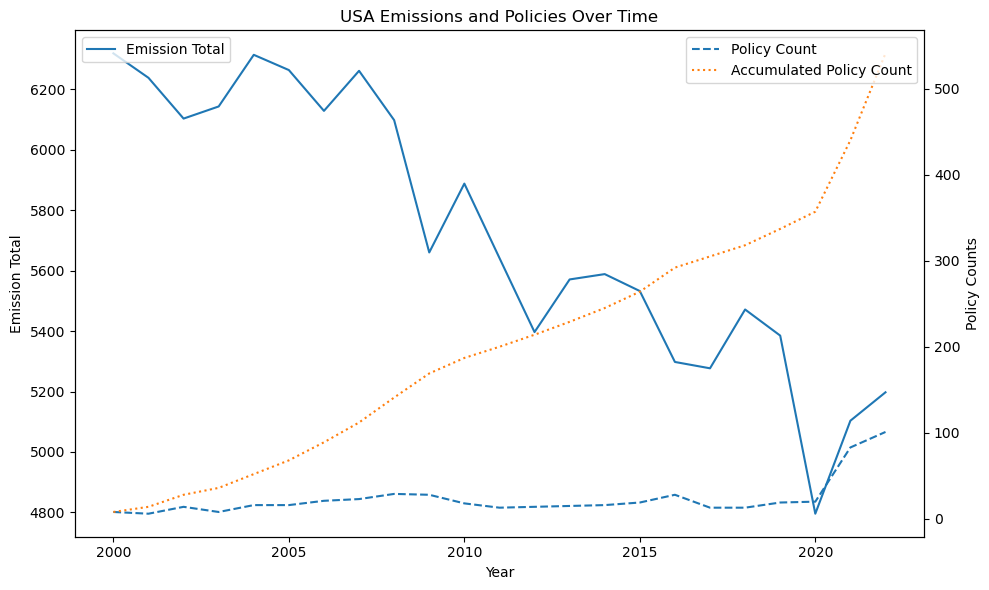

In [ ]:
plot_emission_policy_trajectory('USA', policies_per_country_year, emissions_db_long)

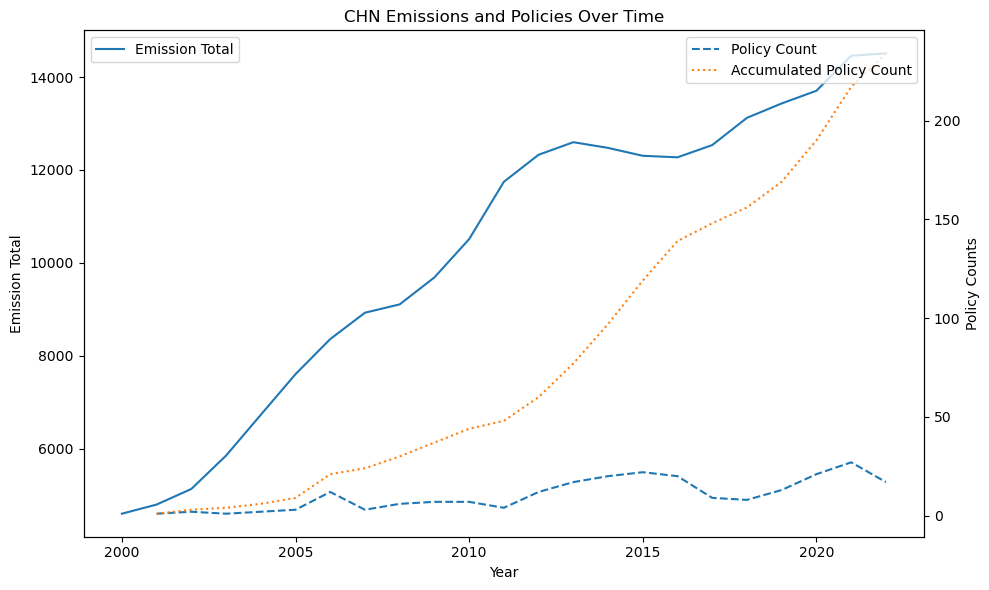

In [ ]:
plot_emission_policy_trajectory('CHN', policies_per_country_year, emissions_db_long)

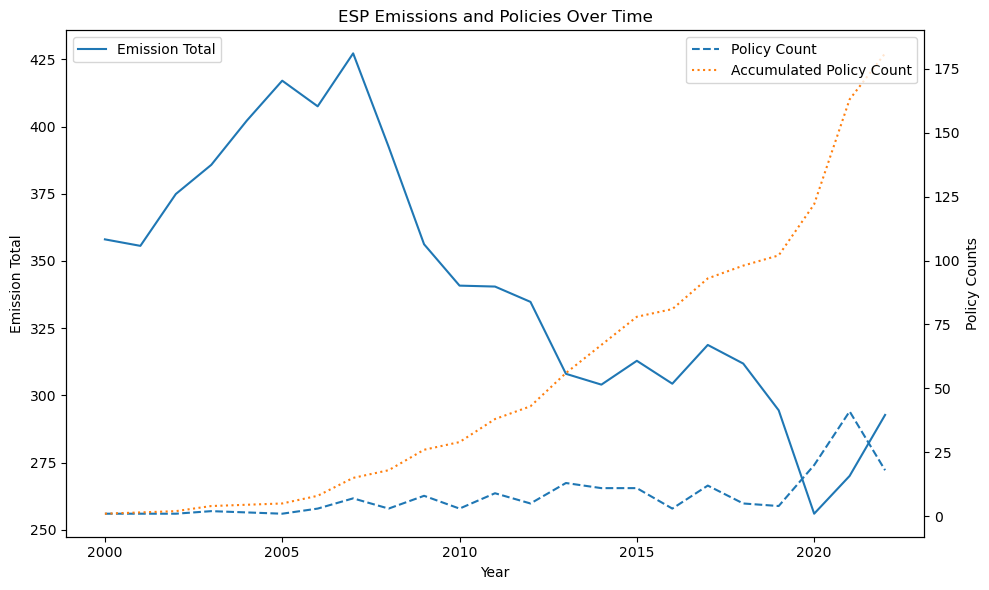

In [ ]:
plot_emission_policy_trajectory('ESP', policies_per_country_year, emissions_db_long)

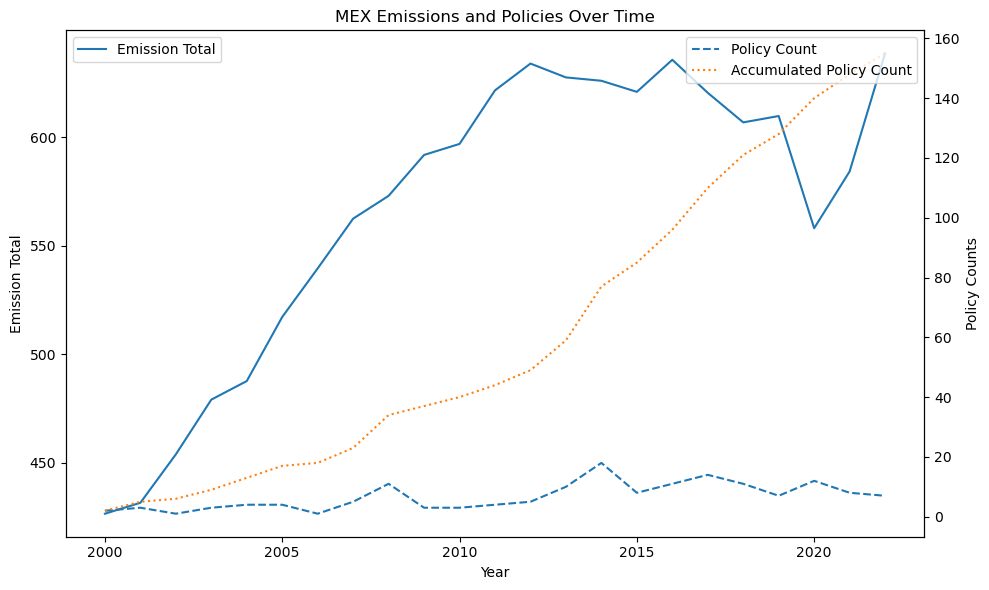

In [ ]:
plot_emission_policy_trajectory('MEX', policies_per_country_year, emissions_db_long)

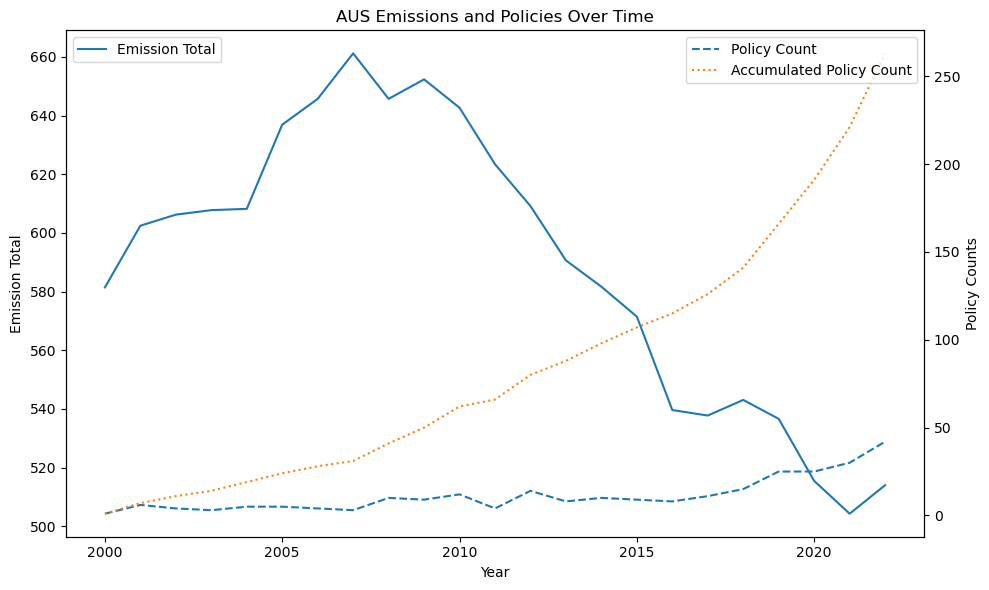

In [ ]:
plot_emission_policy_trajectory('AUS', policies_per_country_year, emissions_db_long)

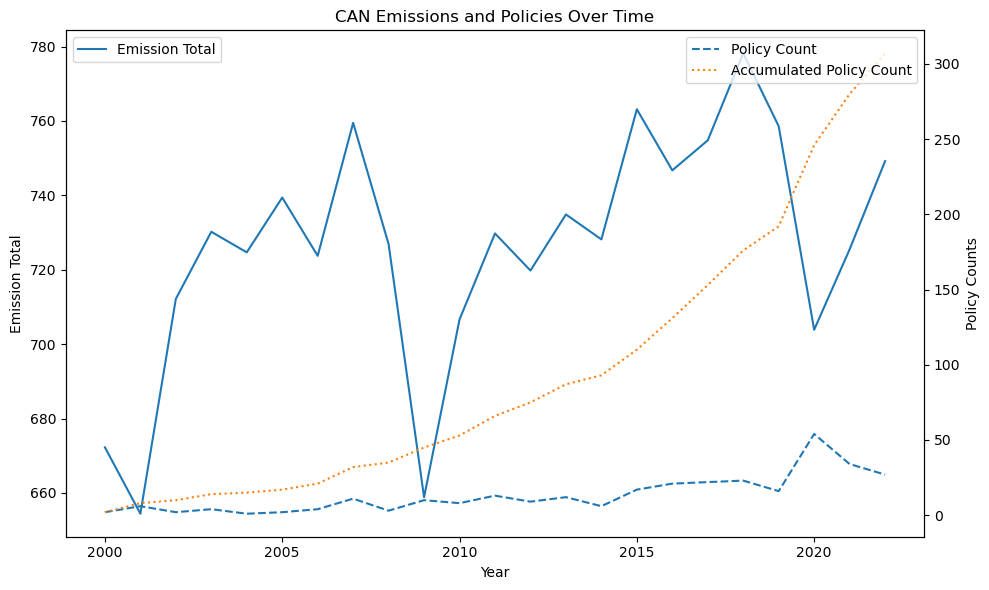

In [ ]:
plot_emission_policy_trajectory('CAN', policies_per_country_year, emissions_db_long)

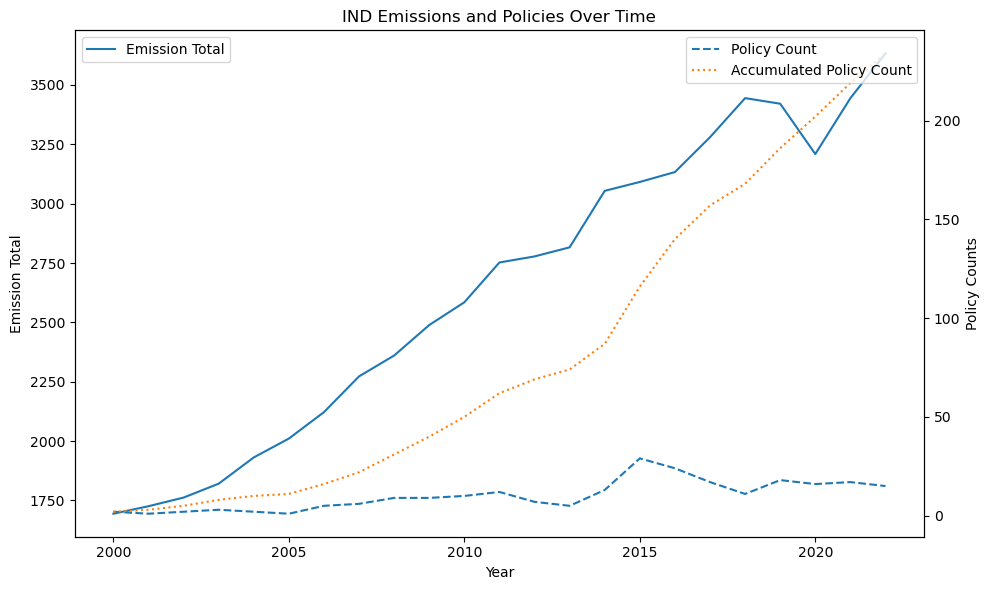

In [ ]:
plot_emission_policy_trajectory('IND', policies_per_country_year, emissions_db_long)

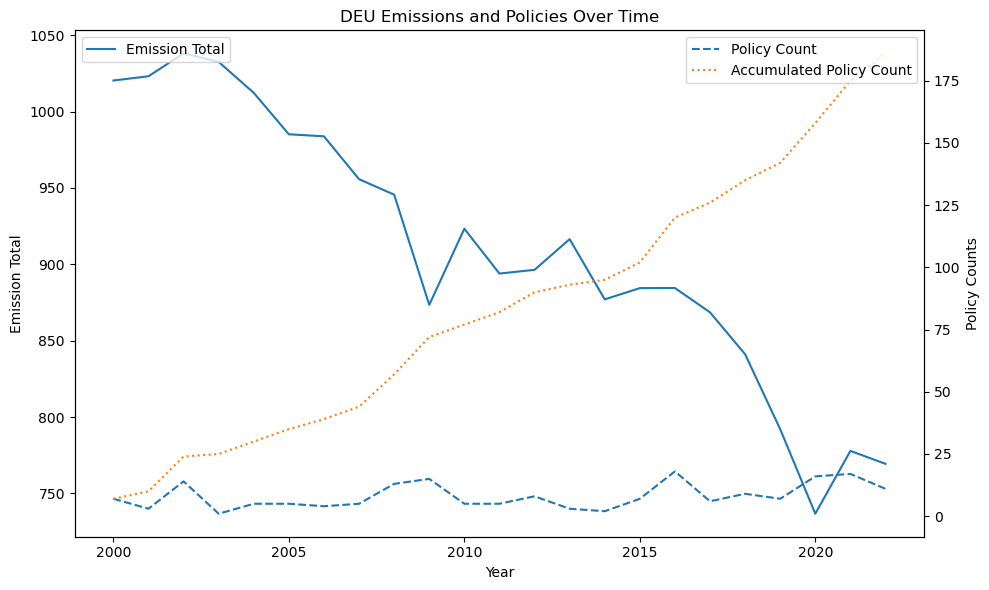

In [ ]:
plot_emission_policy_trajectory('DEU', policies_per_country_year, emissions_db_long)

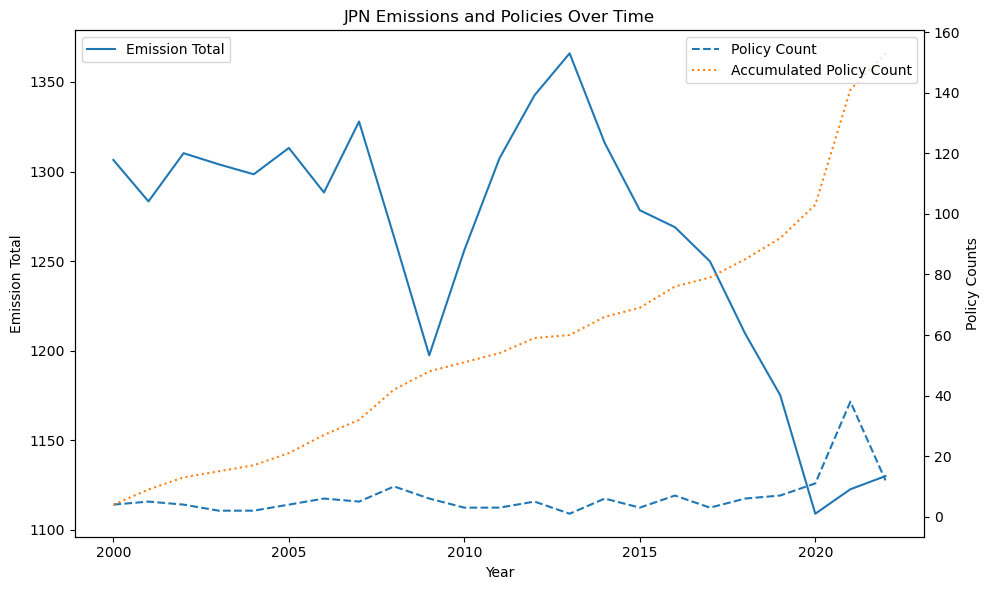

In [ ]:
plot_emission_policy_trajectory('JPN', policies_per_country_year, emissions_db_long)

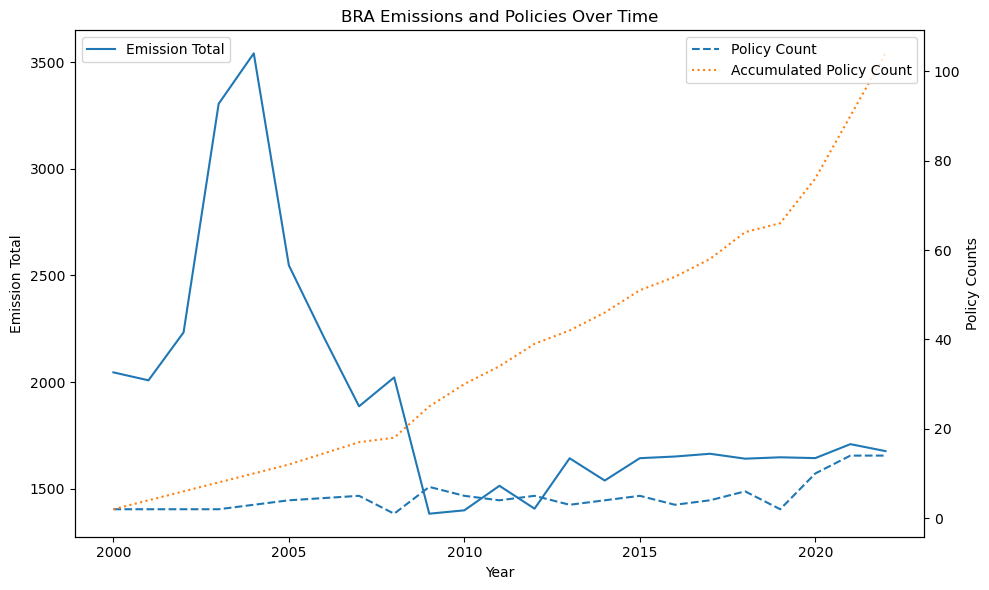

In [ ]:
plot_emission_policy_trajectory('BRA', policies_per_country_year, emissions_db_long)